In [1]:
import earthaccess
import os
import warnings
import csv
import numpy as np
import math
import xarray as xr
import holoviews as hv
import hvplot.xarray
# import netCDF4 as nc
#import cv2 as cv

import glob
import sys
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from scipy import linalg
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
from skimage.transform import hough_line, hough_line_peaks

from config import CONFIG, CROSS_SECTIONS, LOCS
from REFERENCE_PLANTS import REFERENCE_PLANTS
sys.path.append('../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr


In [8]:
loc_name = "New_Madrid_Power_Plant"

imfns = glob.glob(f"{CONFIG['data_folder']}/{loc_name}/*RAD*")
fp = np.random.choice(imfns)
fp =  '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20250616T183008_2516712_025.nc'
# fp = '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20230623T171204_2317411_009.nc'

print(fp)
fp_mask = fp.replace("L1B_RAD", "L2A_MASK")

ds = emit_xarray(fp, ortho = False)
mask_ds = emit_xarray(fp_mask, ortho=False)

mask_key = mask_ds['mask_bands'].to_dataframe()
mask_key

/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20250616T183008_2516712_025.nc


,mask_bands
mask_bands,
Cloud flag,Cloud flag
Cirrus flag,Cirrus flag
Water flag,Water flag
Spacecraft Flag,Spacecraft Flag
Dilated Cloud Flag,Dilated Cloud Flag
AOD550,AOD550
H2O (g cm-2),H2O (g cm-2)
Aggregate Flag,Aggregate Flag


In [9]:
imfns

['/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20230623T171204_2317411_009.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20251128T175512_2533211_023.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20230823T170609_2323511_010.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20240811T205156_2422414_043.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20240205T160510_2403611_023.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20250602T165057_2515311_025.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20250927T182537_2527011_023.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_20240815T191458_2422813_045.nc',
 '/orcd/data/dvaron/001/kgauld/EMIT/data/New_Madrid_Power_Plant/EMIT_L1B_RAD_001_2024120

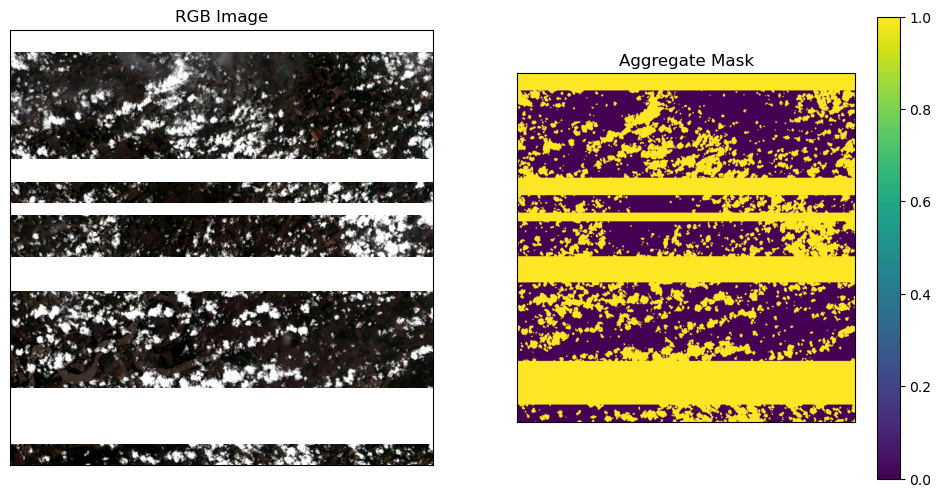

In [10]:
cloud_mask = mask_ds['mask'].values[...,0]
cloud_mask = binary_dilation(cloud_mask, iterations=2)

cirrus_mask = mask_ds['mask'].values[...,1]
water_mask = mask_ds['mask'].values[...,2]
sc_mask = mask_ds['mask'].values[...,3]

agg_mask = np.clip(cloud_mask+cirrus_mask+water_mask+sc_mask, 0, 1)


rgb_inds = np.array([np.nanargmin(abs(ds['wavelengths'].values - x)) for x in [650, 560, 470]])
rgb = ds['radiance'].values[:,:,rgb_inds] # subset RGB
rgb[rgb < 0] = np.nan
rgb -= np.nanpercentile(rgb,2,axis=(0,1))[np.newaxis,np.newaxis,:] # scale from 2-95 %
rgb /= np.nanpercentile(rgb,95,axis=(0,1))[np.newaxis,np.newaxis,:]
rgb = np.clip(rgb, 0, 1)

fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].imshow(rgb)
axs[0].set_title('RGB Image')

im = axs[1].imshow(agg_mask)
plt.colorbar(im, ax=axs[1])
axs[1].set_title('Aggregate Mask')

for a in axs:
    a.set_xticks([])
    a.set_yticks([])

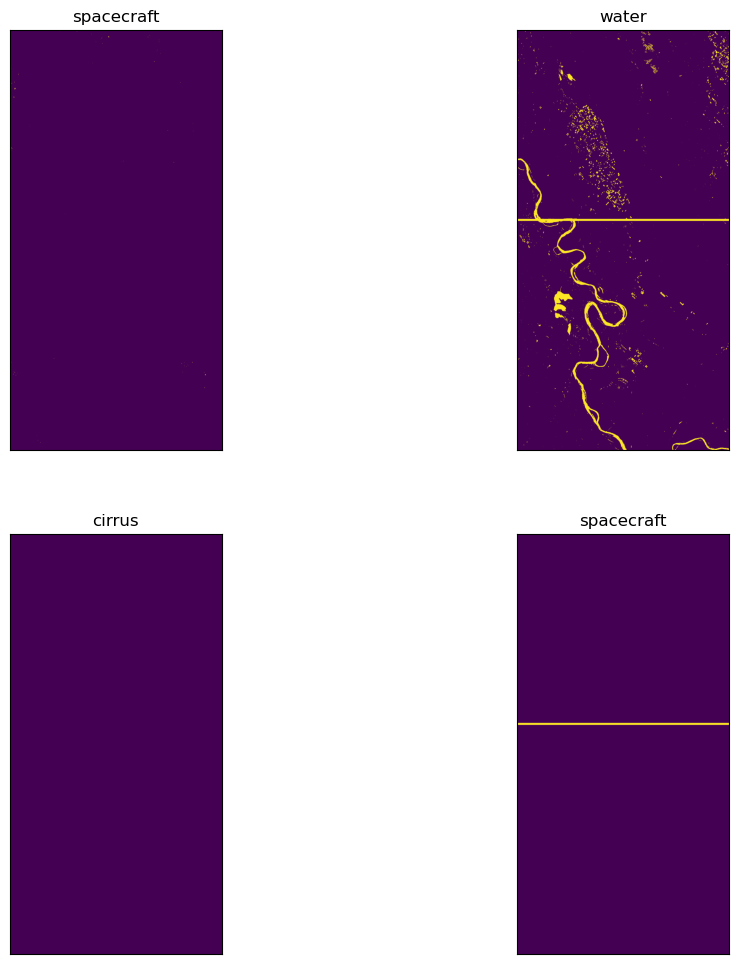

In [38]:
fig, axs = plt.subplots(2,2, figsize=(12,12))

axs[0,0].set_title("spacecraft")
axs[0,0].imshow(cloud_mask)

axs[1,0].set_title("cirrus")
axs[1,0].imshow(cirrus_mask)

axs[0,1].set_title("water")
axs[0,1].imshow(water_mask)

axs[1,1].set_title("spacecraft")
axs[1,1].imshow(sc_mask)

for a in axs.flatten():
    a.set_xticks([])
    a.set_yticks([])